# Regional economic-sentiment index — Huila, Colombia

I build a sentiment index from regional economic news, classifying each item with an LLM (Google Gemini) and aggregating the result over time.

**Own approach:** LLM classification (reads context, not just keywords) · regional scope · stated bias.
**Index method:** simple — (% positive − % negative) per period.

> The news are in Spanish (regional outlets), so the classification prompt is kept in Spanish; all analysis code and notes are in English.


In [1]:
# News dataset produced by a separate scraping step (kept private).
# Columns come from the source in Spanish: año, mes, día, medio, titulo, contenido, url.
import pandas as pd

df = pd.read_excel("data.xlsx")
df["date"] = pd.to_datetime(dict(year=df["año"], month=df["mes"], day=df["día"]))

# Data cleaning: the scraper caught some articles twice (pagination overlap). Drop duplicates.
df = df.drop_duplicates(subset="url").reset_index(drop=True)
df = df[["date", "medio", "titulo", "contenido"]].sort_values("date").reset_index(drop=True)

print(f"{len(df)} unique news items, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


93 unique news items, 2026-08-04 to 2026-09-04


,date,medio,titulo,contenido
0,2026-08-04,Diario del Huila,"Exportaciones de Colombia crecieron 7%, pero c...","Exportaciones de Colombia crecieron 7%, pero c..."
1,2026-08-04,Diario del Huila,"Actividad económica del país creció 2,2% en el...","Actividad económica del país creció 2,2% en el..."
2,2026-08-04,Diario del Huila,Papa baja de precio y alimentos básicos mantie...,Papa baja de precio y alimentos básicos mantie...
3,2026-08-05,Diario del Huila,Colombia exportó más servicios empresariales y...,Colombia exportó más servicios empresariales y...
4,2026-08-06,Diario del Huila,Colombia en alerta: ACP advierte riesgo de des...,Colombia en alerta: ACP advierte riesgo de des...


In [2]:
# Connect to Gemini. The API key is requested at runtime and never stored in the notebook.
from google import genai
import getpass

client = genai.Client(api_key=getpass.getpass("Paste your Gemini API key: "))
print("Client ready")


Client ready


In [3]:
# Classify the economic sentiment of a news item as positive / negative / neutral.
# Prompt is in Spanish because the news are in Spanish; the LLM reads the full context.
def classify_sentiment(title, body):
    prompt = f"""Clasifica el SENTIMIENTO ECONÓMICO de esta noticia según su impacto sobre la economía regional.
Responde SOLO una palabra: positivo, negativo o neutral.

- positivo: mejora económica (crecimiento, empleo, inversión, exportaciones al alza).
- negativo: deterioro (caída, desempleo, cierre, inflación, crisis).
- neutral: informativo sin dirección clara, o efectos mixtos.

Título: {title}
Contenido: {body[:800]}

Respuesta (una palabra):"""
    r = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return r.text.strip().lower()

# Quick check on the first item
classify_sentiment(df.loc[0, "titulo"], df.loc[0, "contenido"])


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


'neutral'

In [4]:
# Classify every item (one API call each; prints progress).
import time

labels = []
for i, row in df.iterrows():
    s = classify_sentiment(row["titulo"], row["contenido"])
    labels.append(s)
    print(f"{i+1}/{len(df)}  ->  {s:9} | {row['titulo'][:55]}")
    time.sleep(0.5)

df["sentiment"] = labels
df["sentiment"].value_counts()


1/93  ->  neutral   | Exportaciones de Colombia crecieron 7%, pero café y flo
2/93  ->  positivo  | Actividad económica del país creció 2,2% en el primer t
3/93  ->  positivo  | Papa baja de precio y alimentos básicos mantienen estab
4/93  ->  positivo  | Colombia exportó más servicios empresariales y de trans
5/93  ->  negativo  | Colombia en alerta: ACP advierte riesgo de desabastecim
6/93  ->  positivo  | Bolsa de Colombia propone reformas para impulsar la inv
7/93  ->  negativo  | Corficolombiana prevé caída del sector agropecuario en 
8/93  ->  negativo  | Precios al productor cayeron 1,42% en julio de 2026.
9/93  ->  negativo  | Retos energéticos del nuevo Gobierno de Colombia.
10/93  ->  negativo  | Petro deja a De la Espriella una economía con desafíos.
11/93  ->  negativo  | Inflación de julio: expertos prevén que llegue al 6,30 
12/93  ->  neutral   | Salario mínimo de 2027: así comienza la discusión en Co
13/93  ->  positivo  | Impuesto al patrimonio: ¿qué cambiará con De la

sentiment
negativo    41
positivo    38
neutral     14
Name: count, dtype: int64

In [5]:
# Persist the LLM-derived labels so the companion notebook (classic_nlp_tfidf.ipynb)
# can train on them without re-calling the API every time.
df[["date", "medio", "titulo", "contenido", "sentiment"]].to_csv("data_labeled.csv", index=False)
print("Saved data_labeled.csv —", len(df), "labeled items")

Saved data_labeled.csv — 93 labeled items


In [6]:
# Index = (% positive - % negative), scaled -100 (all bad) to +100 (all good).
def sentiment_index(group):
    n = len(group)
    return (group.eq("positivo").sum() - group.eq("negativo").sum()) / n * 100

overall = sentiment_index(df["sentiment"])
print(f"Sentiment index — Huila, July 2026: {overall:+.1f}")

# Daily index to see the evolution across the month.
daily = df.groupby(df["date"].dt.date)["sentiment"].apply(sentiment_index)
daily


Sentiment index — Huila, July 2026: -3.2


date
2026-08-04     66.666667
2026-08-05    100.000000
2026-08-06    -50.000000
2026-08-07   -100.000000
2026-08-09    -50.000000
2026-08-10     50.000000
2026-08-11    -50.000000
2026-08-12     40.000000
2026-08-13    -50.000000
2026-08-14     33.333333
2026-08-15      0.000000
2026-08-17   -100.000000
2026-08-18   -100.000000
2026-08-19    -33.333333
2026-08-20     33.333333
2026-08-21     33.333333
2026-08-22    -50.000000
2026-08-23    100.000000
2026-08-24    -42.857143
2026-08-25    -20.000000
2026-08-26      0.000000
2026-08-27      0.000000
2026-08-28      0.000000
2026-08-29    100.000000
2026-08-31    100.000000
2026-09-01      0.000000
2026-09-02     20.000000
2026-09-03     50.000000
2026-09-04    -25.000000
Name: sentiment, dtype: float64

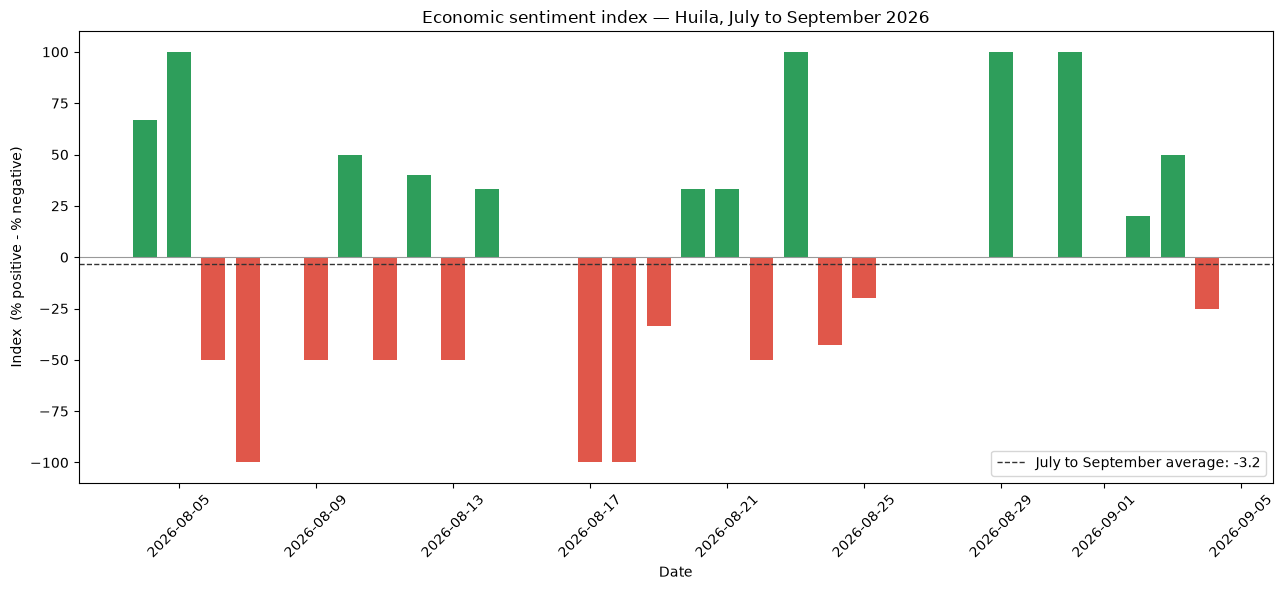

In [12]:
# Daily index: green bars = positive days, red = negative; dashed line = monthly average.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in daily.values]
ax.bar(daily.index, daily.values, color=colors, width=0.7)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"July to September average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title("Economic sentiment index — Huila, July to September 2026")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Date")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig("sentiment_index.png", dpi=120, bbox_inches="tight")


In [8]:
# OPTIONAL — aggregate weekly or monthly to smooth the index as the sample grows.
# The daily view above is volatile because each day has few news items; a coarser
# window (more news per bar) gives a steadier read.
period = "W"          # "W" = weekly, "M" = monthly
agg = df.groupby(df["date"].dt.to_period(period))["sentiment"].apply(sentiment_index)
agg.index = agg.index.astype(str)
print(agg)


date
2026-08-03/2026-08-09   -16.666667
2026-08-10/2026-08-16     5.555556
2026-08-17/2026-08-23   -16.666667
2026-08-24/2026-08-30   -11.538462
2026-08-31/2026-09-06    21.052632
Name: sentiment, dtype: float64


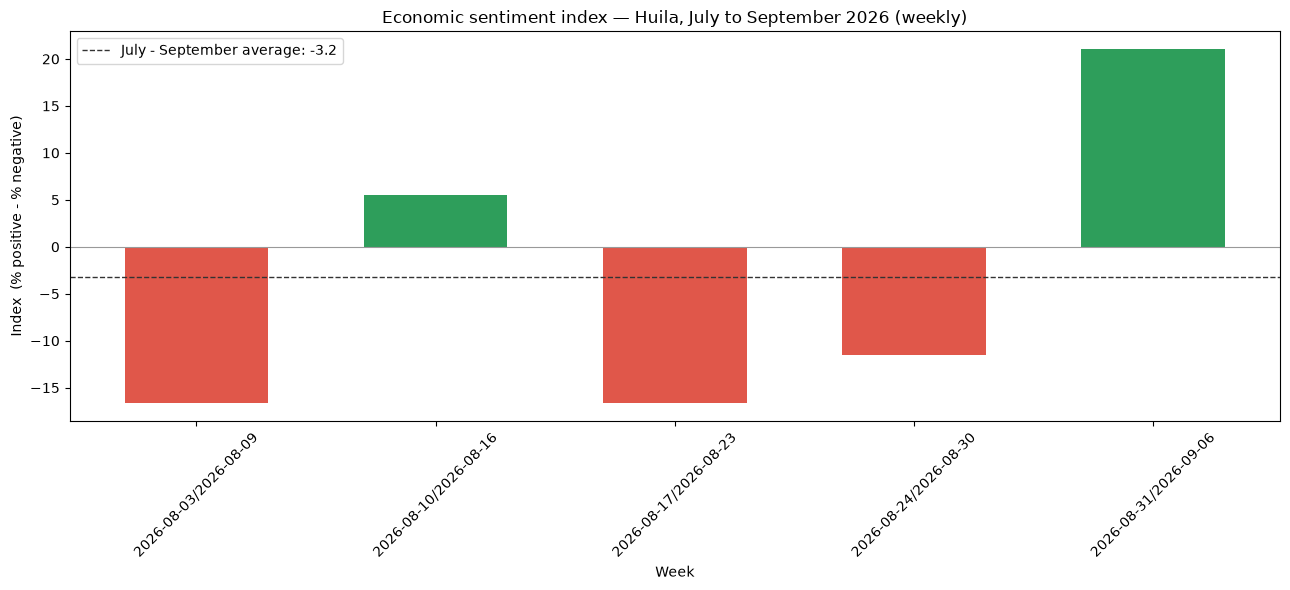

In [13]:
# Aggregated index chart (weekly). Uses `agg` from the optional cell above.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in agg.values]
ax.bar(agg.index, agg.values, color=colors, width=0.6)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"July - September average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title("Economic sentiment index — Huila, July to September 2026 (weekly)")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Week")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig("sentiment_index_weekly.png", dpi=120, bbox_inches="tight")